<a href="https://colab.research.google.com/github/andres-merino/Curso-FundMachineLearning/blob/main/4-Ejercicios/05-SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 20%; vertical-align: middle; padding-right: 10px;">
            <img src="https://i0.wp.com/see-ec.org/wordpress/wp-content/uploads/2023/01/LOGO-SEE-texto-blanco-3.png?w=1356&ssl=1" width="200">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#008dc3" size="7">|</font><br>
            <font color="#008dc3" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#008dc3" size="5">
                <b>Sociedad Ecuatoriana de Estadística</b>
            </font> </p>
            <p style="font-variant: small-caps;"><font color="#008dc3" size="4">
                Aprendizaje Automático Inicial &bull; Máquinas de soporte vectorial
            </font></p>
            <p style="font-style: oblique;"><font color="#008dc3" size="3">
                Andrés Merino &bull; 2025-04
            </font></p>
        </td>  
    </tr>
</table>

---
## <font color='008dc3'> Introducción </font>

A lo largo de este taller, aplicaremos el algoritmo de máquinas de soporte vectorial (SVM) para clasificar un conjunto de datos.

Los paquetes necesarios son:

In [31]:

import pandas as pd  # Manejo de datos
import matplotlib.pyplot as plt  # Visualización

from sklearn.preprocessing import StandardScaler  # Estandarización de datos
from sklearn.datasets import make_blobs, make_circles # Creación de datos
from sklearn.model_selection import train_test_split # División de datos
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Métrica de evaluación

# Algoritmo SVC
from sklearn.svm import SVC

---
## <font color='008dc3'> Clasificación </font>


### <font color='008dc3'> Preprocesamiento de datos </font>

Primero necesitas el conjunto de datos. Los datos a utilzar son los seleccionados en la clase anterior.

<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Carga el conjunto de datos y procésalos:
<ul>
  <li>Muestra algunos datos.</li>
  <li>Muestra una descripción de los datos.</li>
  <li>Escala los datos si es necesario.</li>
</ul>
</div>

In [2]:
# 1. Cargar el dataset
cancer = datasets.load_breast_cancer()
X = cancer.data
y = cancer.target

In [6]:
print("Primeros 5 registros de las características (X):\n", X[:5])
print("Primeros 5 registros de las etiquetas (y):\n", y[:5])
print("\nNombres de las características:\n", cancer.feature_names)
print("\nNombres de los objetivos:\n", cancer.target_names)

Primeros 5 registros de las características (X):
 [[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
  1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
  6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
  1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
  4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
  7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
  5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
  2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
  2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 1.203e+03 1.096e-01 1.599e-01 1.974e-01
  1.279e-01 2.069e-01 5.999e-02 7.456e-01 7.869e-01 4.585e+00 9.403e+01
  6.150e-03 4.006e-02 3.832e-02 2.058e-02 2.250e-02 4.571e-03 2.357e+01
  2.553e+01 1.525e+02 1.709e+03 1.444e-01 4.245e-01 4.504e-01 2.430e-01
  3.613e-01 8.758e-02]
 [1.142e+01 2.038

In [13]:
print("\nDescripción del conjunto de datos de cáncer de mama:\n")
print(cancer.DESCR)



Descripción del conjunto de datos de cáncer de mama:

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field

In [36]:


# Escala los datos si es necesario
# Se recomienda escalar los datos para SVMs.
# Dividir los datos en conjuntos de entrenamiento y prueba antes de escalar para evitar el "data leakage".
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nDatos escalados (primeros 5 registros del conjunto de entrenamiento):\n", X_train_scaled[:5])


Datos escalados (primeros 5 registros del conjunto de entrenamiento):
 [[-1.44075296 -0.43531947 -1.36208497 -1.1391179   0.78057331  0.71892128
   2.82313451 -0.11914956  1.09266219  2.45817261 -0.26380039 -0.01605246
  -0.47041357 -0.47476088  0.83836493  3.25102691  8.43893667  3.39198733
   2.62116574  2.06120787 -1.23286131 -0.47630949 -1.24792009 -0.97396758
   0.72289445  1.18673232  4.67282796  0.9320124   2.09724217  1.88645014]
 [ 1.97409619  1.73302577  2.09167167  1.85197292  1.319843    3.42627493
   2.01311199  2.66503199  2.1270036   1.55839569  0.80531919 -0.81268678
   0.75195659  0.87716951 -0.89605315  1.18122247  0.18362761  0.60059598
  -0.31771686  0.52963649  2.17331385  1.3112795   2.08161691  2.1374055
   0.76192793  3.26560084  1.92862053  2.6989469   1.89116053  2.49783848]
 [-1.39998202 -1.24962228 -1.34520926 -1.10978518 -1.33264483 -0.30735463
  -0.36555756 -0.69650228  1.93033305  0.95437877  0.02752055  1.96305996
  -0.12095781 -0.35077918  0.57276579  


### <font color='008dc3'> Determinación del mejor kernel </font>

<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Determina el mejor kernel para el modelo SVM.
<ul>
  <li>Genera una gráfica que muestre la precisión de los modelos con diferentes kernels.</li>
  <li>Selecciona el mejor kernel.</li>
</ul>
</div>


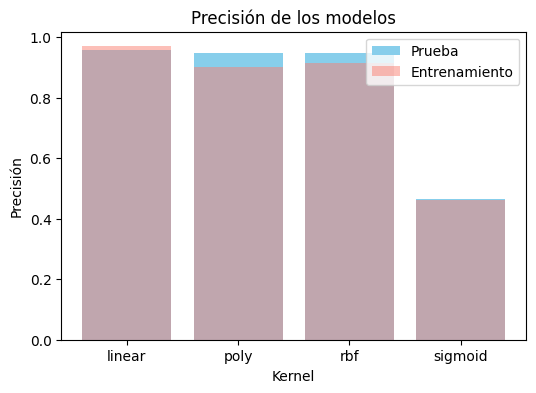

In [39]:
# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Determinar el mejor valor de k
kernel_values = ['linear', 'poly', 'rbf', 'sigmoid']

# Precisión de los modelos
precisions_test = []
precisions_train = []

for kernel in kernel_values:
    modelo = SVC(kernel=kernel)
    modelo.fit(X_train, y_train)
    y_pred_test = modelo.predict(X_test)
    y_pred_train = modelo.predict(X_train)
    precisions_test.append(accuracy_score(y_test, y_pred_test))
    precisions_train.append(accuracy_score(y_train, y_pred_train))

# Visualizar la precisión en función de k con barras
plt.figure(figsize=(6, 4))
plt.bar(kernel_values, precisions_test, color='skyblue')
plt.bar(kernel_values, precisions_train, color='salmon', alpha=0.5)
plt.title('Precisión de los modelos')
plt.xlabel('Kernel')
plt.ylabel('Precisión')
plt.legend(['Prueba', 'Entrenamiento'])
plt.show()

Precisión con kernel 'linear': 0.9561
Precisión con kernel 'poly': 0.8684
Precisión con kernel 'rbf': 0.9825
Precisión con kernel 'sigmoid': 0.9561

El mejor kernel es: 'rbf' con una precisión de 0.9825


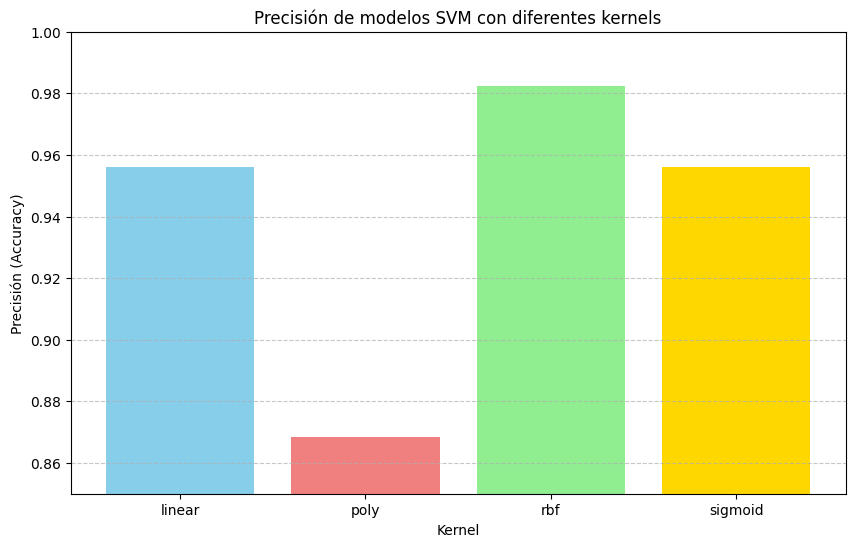

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


kernels = ['linear', 'poly', 'rbf', 'sigmoid']
accuracies = []

for kernel in kernels:
    # Entrenar el modelo SVM con el kernel actual
    svm_model = SVC(kernel=kernel, random_state=42)
    svm_model.fit(X_train_scaled, y_train)

    # Evaluar la precisión del modelo
    accuracy = svm_model.score(X_test_scaled, y_test)
    accuracies.append(accuracy)
    print(f"Precisión con kernel '{kernel}': {accuracy:.4f}")

# Encontrar el mejor kernel
best_kernel_index = accuracies.index(max(accuracies))
best_kernel = kernels[best_kernel_index]
print(f"\nEl mejor kernel es: '{best_kernel}' con una precisión de {accuracies[best_kernel_index]:.4f}")

# Generar una gráfica de barras para visualizar la precisión de los kernels
plt.figure(figsize=(10, 6))
plt.bar(kernels, accuracies, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.xlabel('Kernel')
plt.ylabel('Precisión (Accuracy)')
plt.title('Precisión de modelos SVM con diferentes kernels')
plt.ylim(0.85, 1.0) # Ajustar el límite y para mejor visualización
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### <font color='008dc3'> Entrenamiento del modelo y evaluación </font>


<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Entrena el modelo y evalúalo:
<ul>
  <li>Entrena el modelo con el kernel seleccionado.</li>
  <li>Evalúa el modelo con el conjunto de datos de prueba.</li>
  <li>Genera una matriz de confusión y muestra las métricas de evaluación.</li>
</ul>
</div>

In [27]:
# Entrenar el modelo con el kernel seleccionado (rbf)
best_svm_model = SVC(kernel=best_kernel, random_state=42)
best_svm_model.fit(X_train_scaled, y_train)

# Evaluar el modelo con el conjunto de datos de prueba
y_pred = best_svm_model.predict(X_test_scaled)

# Mostrar métricas de evaluación
print(f"Precisión del modelo con kernel '{best_kernel}': {accuracy_score(y_test, y_pred):.4f}")

# Generar y mostrar la matriz de confusión
print("\nMatriz de Confusión:\n")
print(confusion_matrix(y_test, y_pred))

# Generar y mostrar el informe de clasificación
print("\nInforme de Clasificación:\n")
print(classification_report(y_test, y_pred))

Precisión del modelo con kernel 'rbf': 0.9825

Matriz de Confusión:

[[41  2]
 [ 0 71]]

Informe de Clasificación:

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Compara el modelo con otros algoritmos de clasificación vistos en clases anteriores.
</div>

In [40]:
# Importar el clasificador K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

# Entrenar el modelo KNN
# Se puede experimentar con diferentes valores de n_neighbors (k)
knn_model = KNeighborsClassifier(n_neighbors=5) # n_neighbors es el número de vecinos
knn_model.fit(X_train_scaled, y_train)

# Evaluar el modelo KNN con el conjunto de datos de prueba
y_pred_knn = knn_model.predict(X_test_scaled)

# Mostrar métricas de evaluación para KNN
print("\n--- Evaluación del modelo K-Nearest Neighbors ---")
print(f"Precisión del modelo KNN: {accuracy_score(y_test, y_pred_knn):.4f}")

# Generar y mostrar la matriz de confusión para KNN
print("\nMatriz de Confusión (KNN):\n")
print(confusion_matrix(y_test, y_pred_knn))

# Generar y mostrar el informe de clasificación para KNN
print("\nInforme de Clasificación (KNN):\n")
print(classification_report(y_test, y_pred_knn))

# Comparación con SVM (resultados ya obtenidos)
print("\n--- Comparación con el modelo SVM (Kernel RBF) ---")
print(f"Precisión del modelo SVM: {accuracy_score(y_test, y_pred):.4f}")
print("\nInforme de Clasificación (SVM):\n")
print(classification_report(y_test, y_pred))


--- Evaluación del modelo K-Nearest Neighbors ---
Precisión del modelo KNN: 0.9474

Matriz de Confusión (KNN):

[[40  3]
 [ 3 68]]

Informe de Clasificación (KNN):

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


--- Comparación con el modelo SVM (Kernel RBF) ---
Precisión del modelo SVM: 0.9825

Informe de Clasificación (SVM):

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

